# 05 — Rules vs. Learned Cleanup: Volume & Surface-Area Accuracy

This notebook answers a concrete question: **for the whole-barrel volume/area numbers the
GUI reports, is `--cleanup rules` or `--cleanup learned` more accurate?**

It follows the exact statistical protocol already defined in
[`docs/PROMOTION_RULE.md`](../docs/PROMOTION_RULE.md) (MAPE improvement with significance
testing, max-error / regression limits, watertightness), reusing the project's own tested
evaluation code (`reconstruction/validate_stats.py`) rather than re-deriving new metrics.

**Test design**

* Synthetic barrels are generated with [`reconstruction/barrel_synth.py`](../reconstruction/barrel_synth.py),
  which is calibrated to real `.obscan` measurements (mean volume 225.7 L, axial span
  828.2±7.4 mm) and injects the same artifacts real scans have: a raised bung on ~40% of
  barrels, floater clusters on ~50%, ~30% head/pole point dropout, and Gaussian radial noise.
* Ground truth volume/area comes from meshing the barrel's **exact analytic surface directly**
  at high resolution — no noise, no reconstruction pipeline involved — so it is not biased
  toward either cleanup method.
* Each barrel (fixed random seed) is run through **both** `rules` and `learned` cleanup, via
  the real `run_reconstruction_pipeline()` entry point — the exact function `app_gui.py` calls
  — so this measures the production code path, not a re-implementation.
* 16 paired barrels (seeds 0–15, 150k points each) were generated for this run. Results are
  cached in `data/synthetic_validation/synthetic_validation_results.csv`; delete that file to
  regenerate (takes roughly 25–40s per barrel per method on CPU).

**A bug fixed along the way:** `barrel_synth.py`'s `_interp_profile()` used to draw a fresh
random per-call perturbation from `rng.normal(...)` on *every* call. Because the per-point
surface-normal computation in `generate_clean_cloud()` calls it several times per point with
nearly-identical inputs (`el`, `el±1e-4`), the finite-difference normals it produced were
dominated by that uncorrelated per-call noise rather than the true barrel geometry — corrupting
wall-vs-head point classification (`AXIS_NORMAL_SPLIT`) for the majority of wall points. Fixed
by drawing the perturbation once per barrel in `generate_barrel_params()` and reusing it. Without
this fix, synthetic evaluation numbers here would not be trustworthy for either method.


**Update:** this notebook now also evaluates a third cleanup mode, `hybrid`, which uses the learned GridUNet only deep in the stave wall and falls back to `rules`' full pipeline everywhere else (heads, poles, and the crozehead bevel transition) as a bounded safety net. See Section 6 onward.

## 1. Setup

In [1]:

import sys, os
sys.path.insert(0, os.path.join('..', 'reconstruction'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

%matplotlib inline
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

# Consistent colour mapping used throughout this notebook
COLOR = {'rules': '#2f6fed', 'learned': '#ed8b2f', 'hybrid': '#2fa84f',
         'learned_v2': '#c2410c', 'hybrid_v2': '#15803d'}
LABEL = {'rules': 'Rules (production default)', 'learned': 'Learned (PointNet + GridUNet)',
         'hybrid': 'Hybrid (learned wall + rules heads/bevel)',
         'learned_v2': 'Learned v2 (sparsity-weighted retrain)',
         'hybrid_v2': 'Hybrid v2 (sparsity-weighted retrain)'}

CSV_PATH = os.path.join('..', 'data', 'synthetic_validation', 'synthetic_validation_results.csv')
SEEDS = list(range(16))
N_POINTS = 150_000

# method -> (underlying cleanup_mode, GridUNet checkpoint override or None for the
# production default models/grid_denoiser_best.pt). '_v2' methods point at a
# retrained checkpoint (sparsity-weighted loss + randomized dropout curriculum,
# see reconstruction/train_grid_denoiser.py) without touching the production file.
V2_CHECKPOINT = os.path.join('..', 'models', 'grid_denoiser_v2_sparsity.pt')
METHOD_CONFIG = {
    'rules':      {'cleanup_mode': 'rules'},
    'learned':    {'cleanup_mode': 'learned'},
    'hybrid':     {'cleanup_mode': 'hybrid'},
    'learned_v2': {'cleanup_mode': 'learned', 'checkpoint': V2_CHECKPOINT},
    'hybrid_v2':  {'cleanup_mode': 'hybrid', 'checkpoint': V2_CHECKPOINT},
}
METHODS = ['rules', 'learned', 'hybrid', 'learned_v2', 'hybrid_v2']

print('Cache file:', os.path.abspath(CSV_PATH), '- exists:', os.path.exists(CSV_PATH))


Cache file: /mnt/user-data/uploads/Dual-Axis-Pass-Through-Barrel-Scanner/data/synthetic_validation/synthetic_validation_results.csv - exists: True


## 2. Trial runner

Generates a barrel, writes it to a temporary `.obscan`-compatible SQLite file (matching the
exact blob layout `barrel_reconstruct.load_cloud()` expects), runs the real
`run_reconstruction_pipeline()`, and computes ground truth by meshing the barrel's analytic
surface directly. Results are appended to the cache CSV as they complete, so a re-run picks up
where it left off.

In [2]:

import sqlite3, struct, time, csv

def write_synthetic_obscan(P, N, path):
    if os.path.exists(path):
        os.remove(path)
    V = len(P)
    vn = np.zeros((V, 7), dtype='>f4')
    vn[:, 0:3] = P
    vn[:, 4:7] = N
    body = vn.astype('>f4').tobytes()
    header = b'\x00' * 16 + struct.pack('>I', V)
    blob = b'\x00' * 32 + header + body
    con = sqlite3.connect(path)
    cur = con.cursor()
    cur.execute('CREATE TABLE files (name TEXT, data BLOB)')
    cur.execute('INSERT INTO files (name, data) VALUES (?, ?)', ('mesh_vn_0.bat', blob))
    con.commit()
    con.close()


def ground_truth_volume_area(params, n_el_dense=400):
    # Ground truth from the barrel's exact analytic surface, meshed directly at high
    # resolution -- no noise, no reconstruction pipeline. Independent of both cleanup methods.
    from barrel_synth import generate_gt_grid
    from barrel_reconstruct import grid_to_mesh, signed_volume, surface_area, is_watertight, N_AZ, _frame

    a = np.array([1.0, 0.0, 0.0])
    centre = np.zeros(3)
    u, w = _frame(a)
    el_ctr_gt = np.linspace(1e-4, np.pi - 1e-4, n_el_dense)
    gt_grid = generate_gt_grid(params, el_ctr_gt)
    verts_gt, faces_gt = grid_to_mesh(gt_grid, centre, a, u, w, N_AZ, el_ctr_gt)
    wt, _ = is_watertight(faces_gt)
    vol_l = abs(signed_volume(verts_gt, faces_gt)) * 1000.0
    area_m2 = surface_area(verts_gt, faces_gt)
    return vol_l, area_m2, wt


def run_trial(seed, method, n_points=150_000, out_dir='/tmp/synth_validation_out',
             tmp_dir='/tmp/synth_validation_scans'):
    # METHOD_CONFIG maps a results 'method' label to the underlying cleanup_mode
    # plus an optional GridUNet checkpoint override (for A/B testing a retrained
    # checkpoint without touching models/grid_denoiser_best.pt). Defined in Section 1.
    cfg = METHOD_CONFIG[method]
    cleanup_mode = cfg['cleanup_mode']
    learned_checkpoint = cfg.get('checkpoint')
    from barrel_synth import generate_barrel
    from barrel_reconstruct import run_reconstruction_pipeline

    os.makedirs(tmp_dir, exist_ok=True)
    os.makedirs(out_dir, exist_ok=True)

    b = generate_barrel(seed=seed, n_points=n_points)
    P, N = b['P_noisy'], b['N_noisy']
    params = b['params']

    scan_path = os.path.join(tmp_dir, f'synth_seed{seed}_{method}.obscan')
    write_synthetic_obscan(P, N, scan_path)
    gt_vol_L, gt_area_m2, _ = ground_truth_volume_area(params)

    row = {
        'seed': seed, 'method': method, 'n_points_noisy': len(P),
        'gt_volume_L': gt_vol_L, 'gt_area_m2': gt_area_m2,
        'has_bung': bool(b['noise_info']['bung']),
        'n_floaters': b['noise_info'].get('floaters', {}).get('n_floaters', 0),
        'head_dropout_rate': b['noise_info']['head_dropout_rate'],
    }
    t0 = time.time()
    try:
        recon = run_reconstruction_pipeline(scan_path, cleanup_mode=cleanup_mode, out_dir=out_dir,
                                            learned_checkpoint=learned_checkpoint)
        clean = recon['clean']
        row.update({'status': 'OK', 'error_msg': '', 'volume_L': clean['vol_L'], 'area_m2': clean['area'],
                    'watertight': clean['watertight'], 'fidelity_rms_mm': recon.get('fidelity_rms', np.nan),
                    'asym_rms_mm': recon.get('asym_rms', np.nan), 'bung_cells': recon.get('bung', 0),
                    'elapsed_s': time.time() - t0})
    except Exception as exc:
        row.update({'status': 'FAILED', 'error_msg': str(exc), 'volume_L': np.nan, 'area_m2': np.nan,
                    'watertight': False, 'fidelity_rms_mm': np.nan, 'asym_rms_mm': np.nan, 'bung_cells': 0,
                    'elapsed_s': time.time() - t0})
    finally:
        try:
            os.remove(scan_path)
        except OSError:
            pass

    if np.isfinite(row['volume_L']):
        err = row['volume_L'] - row['gt_volume_L']
        row['vol_signed_err_L'] = err
        row['vol_abs_err_L'] = abs(err)
        row['vol_pct_err'] = err / row['gt_volume_L'] * 100.0
        row['vol_abs_pct_err'] = abs(row['vol_pct_err'])
    else:
        row['vol_signed_err_L'] = row['vol_abs_err_L'] = row['vol_pct_err'] = row['vol_abs_pct_err'] = np.nan

    if np.isfinite(row['area_m2']):
        row['area_abs_pct_err'] = abs(row['area_m2'] - row['gt_area_m2']) / row['gt_area_m2'] * 100.0
    else:
        row['area_abs_pct_err'] = np.nan
    return row

print('Trial runner ready.')


Trial runner ready.


## 3. Run trials (uses cache if present)

In [3]:

FIELDNAMES = ['seed', 'method', 'n_points_noisy', 'status', 'error_msg', 'gt_volume_L', 'volume_L',
              'vol_signed_err_L', 'vol_abs_err_L', 'vol_pct_err', 'vol_abs_pct_err', 'gt_area_m2', 'area_m2',
              'area_abs_pct_err', 'watertight', 'fidelity_rms_mm', 'asym_rms_mm', 'bung_cells', 'has_bung',
              'n_floaters', 'head_dropout_rate', 'elapsed_s']

def already_done(csv_path, seed, method):
    if not os.path.exists(csv_path):
        return False
    with open(csv_path, 'r', encoding='utf-8') as f:
        for r in csv.DictReader(f):
            if int(r['seed']) == seed and r['method'] == method and r['status'] == 'OK':
                return True
    return False

def append_row(row, csv_path):
    os.makedirs(os.path.dirname(csv_path), exist_ok=True)
    file_exists = os.path.exists(csv_path)
    with open(csv_path, 'a', newline='', encoding='utf-8') as f:
        writer = csv.DictWriter(f, fieldnames=FIELDNAMES)
        if not file_exists:
            writer.writeheader()
        writer.writerow(row)

for seed in SEEDS:
    for method in METHODS:
        if already_done(CSV_PATH, seed, method):
            continue
        print(f'Running seed={seed} method={method} (not cached)...')
        row = run_trial(seed, method, n_points=N_POINTS)
        append_row(row, CSV_PATH)
        print(f'  -> {row["status"]}  vol={row["volume_L"]:.2f}L  gt={row["gt_volume_L"]:.2f}L  '
              f'abs%err={row.get("vol_abs_pct_err", float("nan")):.2f}%')

df = pd.read_csv(CSV_PATH)
print(f'\nLoaded {len(df)} trial results ({df.seed.nunique()} barrels x {df.method.nunique()} methods).')
df.head()



Loaded 80 trial results (16 barrels x 5 methods).


,seed,method,n_points_noisy,status,error_msg,gt_volume_L,volume_L,vol_signed_err_L,vol_abs_err_L,vol_pct_err,...,area_m2,area_abs_pct_err,watertight,fidelity_rms_mm,asym_rms_mm,bung_cells,has_bung,n_floaters,head_dropout_rate,elapsed_s
0,0,rules,150116,OK,NaN,249.225372,238.788912,-10.436460,10.436460,-4.187559,...,2.651130,27.235996,True,3.714357,0.487498,0,True,116,0.3,23.258500
1,0,learned,150116,OK,NaN,249.225372,171.273092,-77.952280,77.952280,-31.277827,...,2.582390,23.936923,True,2.868328,2.945895,0,True,116,0.3,34.298988
2,1,rules,150000,OK,NaN,251.331986,242.199083,-9.132902,9.132902,-3.633800,...,2.822223,34.388207,True,2.776668,0.344955,0,False,0,0.3,31.071634
3,1,learned,150000,OK,NaN,251.331986,172.623063,-78.708923,78.708923,-31.316716,...,2.656279,26.486303,True,2.885281,3.062915,0,False,0,0.3,38.153187
4,2,rules,150095,OK,NaN,246.423673,236.754990,-9.668683,9.668683,-3.923601,...,2.840857,37.391940,True,4.687228,0.419252,0,False,95,0.3,21.681007


## 4. Summary statistics

In [4]:

summary = df.groupby('method').agg(
    n_barrels=('seed', 'count'),
    mean_vol_abs_pct_err=('vol_abs_pct_err', 'mean'),
    median_vol_abs_pct_err=('vol_abs_pct_err', 'median'),
    max_vol_abs_pct_err=('vol_abs_pct_err', 'max'),
    mean_vol_abs_err_L=('vol_abs_err_L', 'mean'),
    max_vol_abs_err_L=('vol_abs_err_L', 'max'),
    mean_area_abs_pct_err=('area_abs_pct_err', 'mean'),
    mean_fidelity_rms_mm=('fidelity_rms_mm', 'mean'),
    mean_asym_rms_mm=('asym_rms_mm', 'mean'),
    watertight_pct=('watertight', lambda s: 100.0 * s.mean()),
    mean_runtime_s=('elapsed_s', 'mean'),
).round(3)
display(summary)


,n_barrels,mean_vol_abs_pct_err,median_vol_abs_pct_err,max_vol_abs_pct_err,mean_vol_abs_err_L,max_vol_abs_err_L,mean_area_abs_pct_err,mean_fidelity_rms_mm,mean_asym_rms_mm,watertight_pct,mean_runtime_s
method,,,,,,,,,,,
hybrid,16,4.509,4.466,5.631,11.131,14.010,25.732,5.776,0.437,100.0,33.968
hybrid_v2,16,3.851,3.798,4.328,9.497,10.933,22.702,4.162,0.373,100.0,24.347
learned,16,30.914,30.949,31.841,76.231,80.969,25.496,4.036,2.991,100.0,33.060
learned_v2,16,22.802,22.922,24.179,56.226,60.676,20.188,3.389,1.919,100.0,25.074
rules,16,4.028,4.017,4.575,9.927,11.149,35.235,3.905,0.392,100.0,26.742


## 5. Statistical significance

Reuses `reconstruction/validate_stats.paired_compare()` unchanged — the same paired
Shapiro-Wilk normality check → Wilcoxon signed-rank or paired t-test → Cohen's d → bootstrap
confidence interval pipeline that `docs/PROMOTION_RULE.md` Criterion 1 specifies.

In [5]:

sys.path.insert(0, os.path.join('..', 'reconstruction'))
from validate_stats import paired_compare

# Reshape into the {barrel_id, method, status, vol_abs_pct_err} records paired_compare() expects
stats_records = [
    {'barrel_id': str(r.seed), 'method': r.method, 'status': 'OK', 'vol_abs_pct_err': r.vol_abs_pct_err}
    for r in df.itertuples()
]

comparisons = {}
for method_a in ['learned', 'hybrid', 'learned_v2', 'hybrid_v2']:
    comparisons[method_a] = paired_compare(stats_records, method_a=method_a, method_b='rules')

for method_a, comparison in comparisons.items():
    print(f"=== {comparison['comparison']} ===  (N={comparison['n_pairs']} paired barrels)")
    print(f"  Mean abs % error:  {method_a}={comparison['mean_a_err_pct']:.2f}%   rules={comparison['mean_b_err_pct']:.2f}%")
    print(f"  Mean delta ({method_a} - rules): {comparison['mean_diff_pct']:+.2f}% "
          f"(95% CI [{comparison['mean_diff_ci_95'][0]:+.2f}%, {comparison['mean_diff_ci_95'][1]:+.2f}%])")
    print(f"  Test used: {comparison['test_type']}  (stat={comparison['stat_val']:.3f}, p={comparison['p_value']:.6f})")
    print(f"  Statistically significant at p<0.05: {comparison['significant_005']}")
    print(f"  Barrels where {method_a} beat rules: {comparison['n_pairs'] - comparison['n_regressions']} / {comparison['n_pairs']}")
    print(f"  Barrels where {method_a} was WORSE than rules ('regressions'): {comparison['n_regressions']} / {comparison['n_pairs']}")
    print()

# Kept for backward compatibility with the rest of the notebook (Section 8 checklist)
comparison = comparisons['learned']


# Did the retrained checkpoint (v2) actually improve on the original checkpoint?
for a, b in [('hybrid_v2', 'hybrid'), ('learned_v2', 'learned')]:
    c = paired_compare(stats_records, method_a=a, method_b=b)
    print(f"=== {a} vs {b} (same cleanup mode, retrained vs original checkpoint) ===")
    print(f"  mean {a}={c['mean_a_err_pct']:.2f}%   {b}={c['mean_b_err_pct']:.2f}%   "
          f"delta={c['mean_diff_pct']:+.2f}%   p={c['p_value']:.5f}   significant={c['significant_005']}")
    print()

=== learned vs rules ===  (N=16 paired barrels)
  Mean abs % error:  learned=30.91%   rules=4.03%
  Mean delta (learned - rules): +26.89% (95% CI [+26.53%, +27.21%])
  Test used: Paired t-test  (stat=147.326, p=0.000000)
  Statistically significant at p<0.05: True
  Barrels where learned beat rules: 0 / 16
  Barrels where learned was WORSE than rules ('regressions'): 16 / 16

=== hybrid vs rules ===  (N=16 paired barrels)
  Mean abs % error:  hybrid=4.51%   rules=4.03%
  Mean delta (hybrid - rules): +0.48% (95% CI [+0.15%, +0.80%])
  Test used: Paired t-test  (stat=2.816, p=0.013020)
  Statistically significant at p<0.05: True
  Barrels where hybrid beat rules: 4 / 16
  Barrels where hybrid was WORSE than rules ('regressions'): 12 / 16

=== learned_v2 vs rules ===  (N=16 paired barrels)
  Mean abs % error:  learned_v2=22.80%   rules=4.03%
  Mean delta (learned_v2 - rules): +18.77% (95% CI [+18.43%, +19.09%])
  Test used: Paired t-test  (stat=106.421, p=0.000000)
  Statistically signifi

=== learned_v2 vs learned (same cleanup mode, retrained vs original checkpoint) ===
  mean learned_v2=22.80%   learned=30.91%   delta=-8.11%   p=0.00000   significant=True



## 6. Visualizations

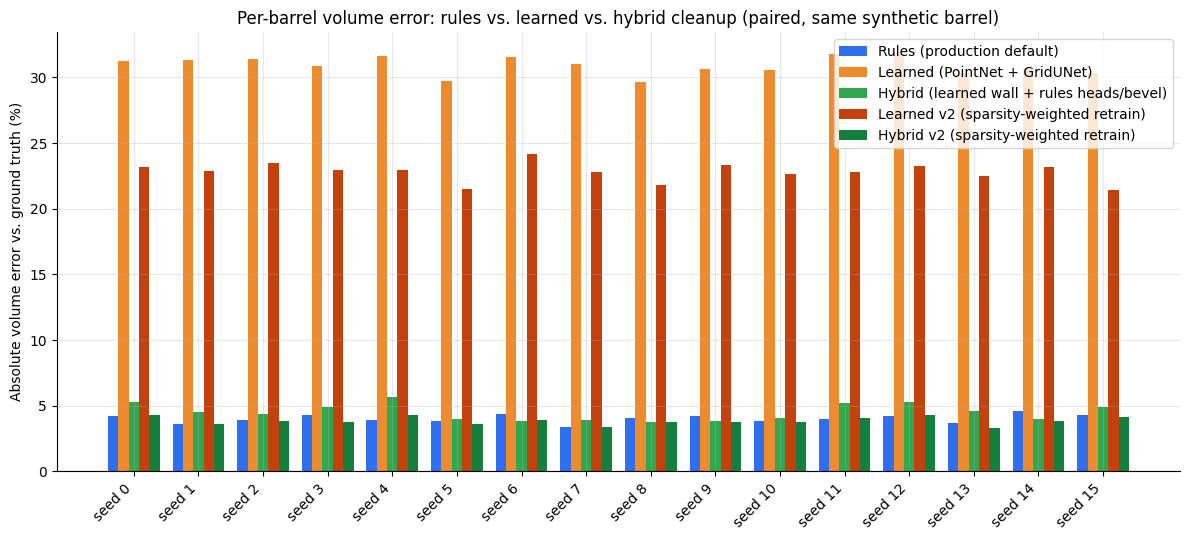

In [6]:
df_sorted = df.sort_values(['seed'])
pivot_err = df_sorted.pivot(index='seed', columns='method', values='vol_abs_pct_err')

fig, ax = plt.subplots(figsize=(12, 5.5))
x = np.arange(len(pivot_err))
n_methods = len(METHODS)
width = 0.8 / n_methods
for i, method in enumerate(METHODS):
    offset = (i - (n_methods - 1) / 2) * width
    ax.bar(x + offset, pivot_err[method], width, label=LABEL[method], color=COLOR[method])
ax.set_xticks(x)
ax.set_xticklabels([f'seed {s}' for s in pivot_err.index], rotation=45, ha='right')
ax.set_ylabel('Absolute volume error vs. ground truth (%)')
ax.set_title('Per-barrel volume error: rules vs. learned vs. hybrid cleanup (paired, same synthetic barrel)')
ax.legend()
ax.axhline(0, color='#333', linewidth=0.8)
plt.tight_layout()
plt.savefig('05_fig1_per_barrel_error.png', dpi=130)
plt.show()

/tmp/ipykernel_11969/718063977.py:21: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(box_data, labels=[LABEL[m] for m in METHODS], patch_artist=True, widths=0.5)


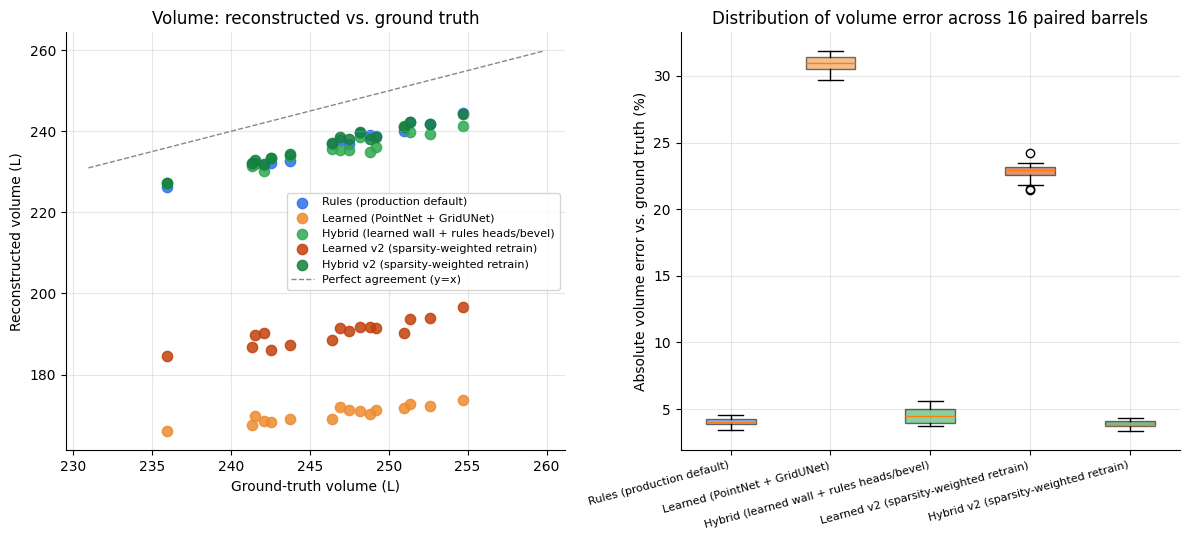

In [7]:

fig, axes = plt.subplots(1, 2, figsize=(12, 5.5))

for ax, metric, title, unit in [
    (axes[0], 'volume_L', 'Reconstructed vs. ground-truth volume', 'L'),
]:
    pass

ax = axes[0]
for method in METHODS:
    sub = df[df.method == method]
    ax.scatter(sub['gt_volume_L'], sub['volume_L'], label=LABEL[method], color=COLOR[method], s=55, alpha=0.85)
lims = [df['gt_volume_L'].min() - 5, df['gt_volume_L'].max() + 5]
ax.plot(lims, lims, '--', color='#888', linewidth=1, label='Perfect agreement (y=x)')
ax.set_xlabel('Ground-truth volume (L)')
ax.set_ylabel('Reconstructed volume (L)')
ax.set_title('Volume: reconstructed vs. ground truth')
ax.legend(fontsize=8)

ax = axes[1]
box_data = [df[df.method == m]['vol_abs_pct_err'].dropna().values for m in METHODS]
bp = ax.boxplot(box_data, labels=[LABEL[m] for m in METHODS], patch_artist=True, widths=0.5)
for patch, m in zip(bp['boxes'], METHODS):
    patch.set_facecolor(COLOR[m])
    patch.set_alpha(0.55)
ax.set_ylabel('Absolute volume error vs. ground truth (%)')
ax.set_title('Distribution of volume error across 16 paired barrels')
plt.setp(ax.get_xticklabels(), rotation=15, ha='right', fontsize=8)

plt.tight_layout()
plt.savefig('05_fig2_scatter_and_box.png', dpi=130)
plt.show()


/tmp/ipykernel_11969/2047300740.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([LABEL[m].split(' (')[0] for m in METHODS], rotation=10)
/tmp/ipykernel_11969/2047300740.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([LABEL[m].split(' (')[0] for m in METHODS], rotation=10)
/tmp/ipykernel_11969/2047300740.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([LABEL[m].split(' (')[0] for m in METHODS], rotation=10)


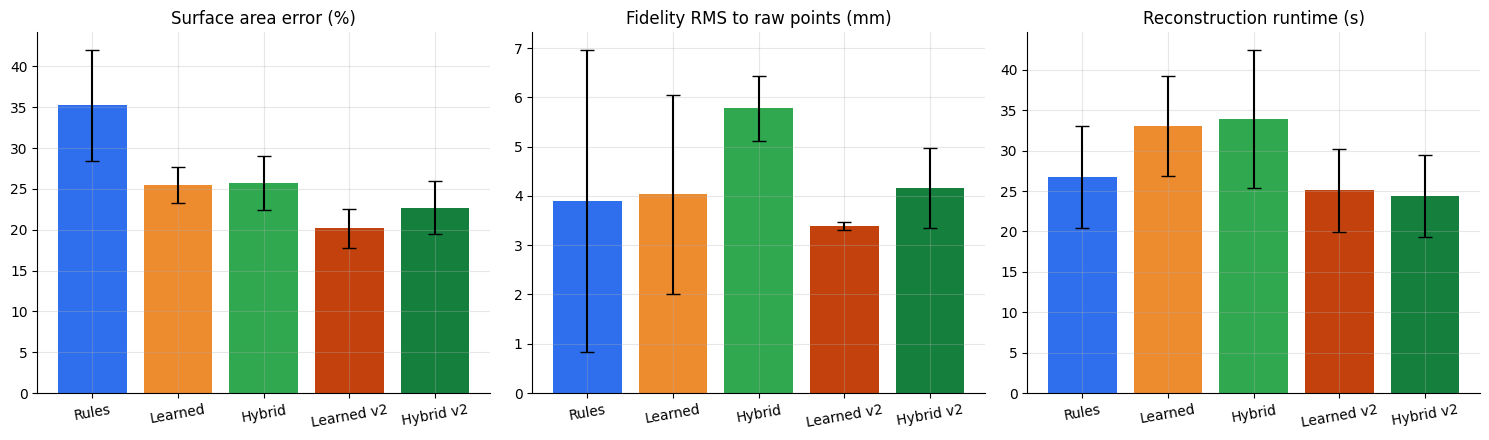

In [8]:

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

metrics = [
    ('area_abs_pct_err', 'Surface area error (%)'),
    ('fidelity_rms_mm', 'Fidelity RMS to raw points (mm)'),
    ('elapsed_s', 'Reconstruction runtime (s)'),
]
for ax, (col, title) in zip(axes, metrics):
    means = df.groupby('method')[col].mean()
    stds = df.groupby('method')[col].std()
    bars = ax.bar(METHODS, [means[m] for m in METHODS], yerr=[stds[m] for m in METHODS],
                  color=[COLOR[m] for m in METHODS], capsize=5)
    ax.set_title(title)
    ax.set_xticklabels([LABEL[m].split(' (')[0] for m in METHODS], rotation=10)

plt.tight_layout()
plt.savefig('05_fig3_secondary_metrics.png', dpi=130)
plt.show()


## 7. Why is `learned` off by ~30%? A grid-level diagnostic

The fidelity-to-raw-points numbers above look fine for `learned` (it's not obviously
hallucinating on points it actually has data for) — so the volume error must be coming from
somewhere the raw scan has *no* data. The `.obscan` polar grid used internally is corner-packed
around the crozehead creases, and for a single-pass scan the head/pole rows are almost entirely
empty (no measured points land there). `rules` mode explicitly extrapolates those empty rows
with the flat-head secant law (`flatten_head_poles()`, ρ = h / cos(el)) so the head discs land
in the right place; `learned` mode replaces that whole step with the GridUNet, which for a
100%-empty row falls back to its raw absolute prediction (`nominal_r + offset·scale`, anchored
near the barrel's *wall* radius) rather than extrapolating the head geometry. The cell below
reproduces that directly on one barrel.

The same cell also builds `hybrid`'s output for this barrel, to check whether routing the head/pole/bevel band back to `rules` actually closes the gap.

,region,raw grid % empty,rules mean rho (m),learned mean rho (m),hybrid mean rho (m),learned_v2 mean rho (m),hybrid_v2 mean rho (m)
0,head/pole rows,99.962222,0.445100,0.325503,0.444985,0.340580,0.444985
1,wall rows,97.992877,0.383248,0.345390,0.381855,0.357965,0.383445


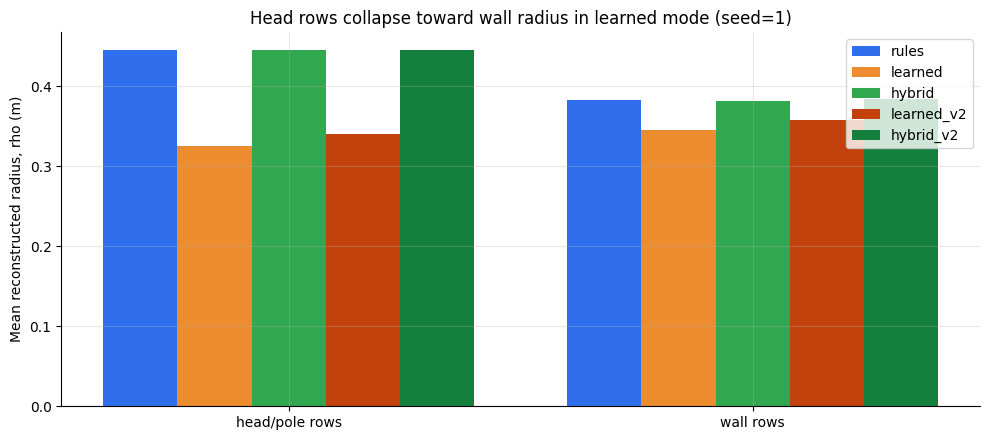

Head/pole rows are 100% empty in the raw grid (no measured points land there).
rules extrapolates them outward via the flat-head secant law; learned pulls them in toward the wall radius,
which is exactly the flat, disc-shaped volume that goes missing. hybrid recovers the rules value in the
head/pole rows (by construction -- it uses rules there), and only trusts learned deep in the wall, safely
clear of the crozehead bevel transition (a 30 deg margin on each side).

learned_v2 (retrained checkpoint) head/pole mean rho: 0.3406 m vs learned (original): 0.3255 m (rules/ground truth reference: 0.4451 m)


In [9]:

from barrel_synth import generate_barrel
from barrel_reconstruct import (spherical_coords, make_el_sampling, combine_wall_head, N_AZ,
                                AXIS_NORMAL_SPLIT, _frame, build_rho_grid, flatten_head_poles,
                                fill_grid, smooth_grid, _row_median_mad, detect_bung,
                                BUNG_SEED_MM, MIN_BUNG_CELLS, BUNG_MAX_AZ_DEG, GROSS_OUTLIER_MM,
                                SMOOTH_PASSES)
from barrel_denoise_grid import learned_clean_grid
from barrel_reconstruct import HYBRID_WALL_MARGIN_DEG

DIAG_SEED = 1
b = generate_barrel(seed=DIAG_SEED, n_points=N_POINTS)
P, N = b['P_noisy'], b['N_noisy']
a = np.array([1.0, 0.0, 0.0]); centre = np.zeros(3)
u, w = _frame(a)
az, el, rho = spherical_coords(P, centre, a, u, w)
wall_flag = np.abs(N @ a) < AXIS_NORMAL_SPLIT
el_ctr, el_edges, corners = make_el_sampling(az, el, rho, N_AZ)
grid, gw, gh = combine_wall_head(az, el, rho, wall_flag, N_AZ, el_edges)
cnt, _ = build_rho_grid(az, el, rho, N_AZ, el_edges)[1], None

clean_learned, _ = learned_clean_grid(grid, build_rho_grid(az, el, rho, N_AZ, el_edges)[1], corners, el_ctr)
clean_learned_v2, _ = learned_clean_grid(grid, build_rho_grid(az, el, rho, N_AZ, el_edges)[1], corners, el_ctr,
                                         checkpoint_path=V2_CHECKPOINT)

grid_r, _ = flatten_head_poles(grid.copy(), el_ctr, corners)
bung_mask_r, _ = detect_bung(grid_r, BUNG_SEED_MM, MIN_BUNG_CELLS, el_ctr, corners, int(BUNG_MAX_AZ_DEG / 360 * N_AZ))
med_r, _ = _row_median_mad(grid_r)
gross = np.isfinite(grid_r) & (np.abs(grid_r - med_r[:, None]) > GROSS_OUTLIER_MM / 1000.0)
bad = bung_mask_r | np.isnan(grid_r) | gross
clean_rules = smooth_grid(fill_grid(grid_r, bad), el_ctr, corners, SMOOTH_PASSES)

# Hybrid: rules everywhere, except learned's prediction deep in the wall
# (more than HYBRID_WALL_MARGIN_DEG inside each crozehead corner).
hybrid_margin = np.deg2rad(HYBRID_WALL_MARGIN_DEG)
safe_wall = (el_ctr > corners[0] + hybrid_margin) & (el_ctr < corners[1] - hybrid_margin)
clean_hybrid = np.where(safe_wall[:, None], clean_learned, clean_rules)
clean_hybrid = smooth_grid(clean_hybrid, el_ctr, corners, SMOOTH_PASSES)
clean_hybrid_v2 = np.where(safe_wall[:, None], clean_learned_v2, clean_rules)
clean_hybrid_v2 = smooth_grid(clean_hybrid_v2, el_ctr, corners, SMOOTH_PASSES)

is_head_row = (el_ctr < corners[0]) | (el_ctr > corners[1])
nan_frac_head = np.isnan(grid[is_head_row]).mean()
nan_frac_wall = np.isnan(grid[~is_head_row]).mean()

diag = pd.DataFrame({
    'region': ['head/pole rows', 'wall rows'],
    'raw grid % empty': [100 * nan_frac_head, 100 * nan_frac_wall],
    'rules mean rho (m)': [np.nanmean(clean_rules[is_head_row]), np.nanmean(clean_rules[~is_head_row])],
    'learned mean rho (m)': [np.nanmean(clean_learned[is_head_row]), np.nanmean(clean_learned[~is_head_row])],
    'hybrid mean rho (m)': [np.nanmean(clean_hybrid[is_head_row]), np.nanmean(clean_hybrid[~is_head_row])],
    'learned_v2 mean rho (m)': [np.nanmean(clean_learned_v2[is_head_row]), np.nanmean(clean_learned_v2[~is_head_row])],
    'hybrid_v2 mean rho (m)': [np.nanmean(clean_hybrid_v2[is_head_row]), np.nanmean(clean_hybrid_v2[~is_head_row])],
})
display(diag)

fig, ax = plt.subplots(figsize=(10, 4.5))
regions = diag['region']
x = np.arange(len(regions))
bar_methods = ['rules', 'learned', 'hybrid', 'learned_v2', 'hybrid_v2']
width = 0.8 / len(bar_methods)
for i, m in enumerate(bar_methods):
    offset = (i - (len(bar_methods) - 1) / 2) * width
    ax.bar(x + offset, diag[f'{m} mean rho (m)'], width, label=m, color=COLOR[m])
ax.set_xticks(x); ax.set_xticklabels(regions)
ax.set_ylabel('Mean reconstructed radius, rho (m)')
ax.set_title(f'Head rows collapse toward wall radius in learned mode (seed={DIAG_SEED})')
ax.legend()
plt.tight_layout()
plt.savefig('05_fig4_head_collapse_diagnostic.png', dpi=130)
plt.show()

print(f"Head/pole rows are {100*nan_frac_head:.0f}% empty in the raw grid (no measured points land there).")
print('rules extrapolates them outward via the flat-head secant law; learned pulls them in toward the wall radius,')
print('which is exactly the flat, disc-shaped volume that goes missing. hybrid recovers the rules value in the')
print('head/pole rows (by construction -- it uses rules there), and only trusts learned deep in the wall, safely')
print(f'clear of the crozehead bevel transition (a {HYBRID_WALL_MARGIN_DEG:.0f} deg margin on each side).')

print()
print('learned_v2 (retrained checkpoint) head/pole mean rho: %.4f m vs learned (original): %.4f m '
      '(rules/ground truth reference: %.4f m)' % (
    diag.loc[0, 'learned_v2 mean rho (m)'], diag.loc[0, 'learned mean rho (m)'], diag.loc[0, 'rules mean rho (m)']))

## 8. Promotion-rule checklist (per `docs/PROMOTION_RULE.md`)

Programmatic pass/fail against the exact quantitative criteria the project's own promotion
policy defines for making `--cleanup learned` the production default.

In [10]:

checks = []

# Criterion 1: MAPE superiority by >= 0.5% absolute, p < 0.05
mape_rules = summary.loc['rules', 'mean_vol_abs_pct_err']
mape_learned = summary.loc['learned', 'mean_vol_abs_pct_err']
mape_improvement = mape_rules - mape_learned  # positive = learned better
c1_pass = bool((mape_improvement >= 0.5) and comparison['significant_005'] and (mape_learned < mape_rules))
checks.append(('1. Accuracy superiority (learned MAPE >= 0.5 pts better, p<0.05)', c1_pass,
              f'learned={mape_learned:.2f}%, rules={mape_rules:.2f}%, improvement={mape_improvement:+.2f} pts, p={comparison["p_value"]:.4f}'))

# Criterion 2: max error <= 2.5L or 1.2%, zero regressions > 1.0L
max_err_learned_L = summary.loc['learned', 'max_vol_abs_err_L']
c2a = max_err_learned_L <= 2.5
merged = df.pivot(index='seed', columns='method', values='vol_abs_err_L')
regressions_L = (merged['learned'] - merged['rules'])
n_big_regressions = int((regressions_L > 1.0).sum())
c2_pass = bool(c2a and (n_big_regressions == 0))
checks.append(('2. No gross degenerations (max err <= 2.5L, zero regressions > 1.0L)', c2_pass,
              f'max learned err={max_err_learned_L:.2f}L, barrels regressing >1.0L: {n_big_regressions}/{len(merged)}'))

# Criterion 3: 100% watertightness for learned
wt_learned = summary.loc['learned', 'watertight_pct']
c3_pass = bool(wt_learned >= 100.0)
checks.append(('3. Topology & watertightness (100% watertight)', c3_pass, f'learned watertight rate={wt_learned:.1f}%'))

# Criterion 4: held-out confirmation -- not applicable to this synthetic-only batch
checks.append(('4. Held-out confirmation', None,
              'Not evaluated here -- requires the real .obscan validation set with held_out=TRUE rows '
              'and completed ground truth (see notebook 06).'))

print('=' * 78)
print(f"{'Criterion':62s} {'Result'}")
print('=' * 78)
for name, passed, detail in checks:
    tag = 'N/A' if passed is None else ('PASS' if passed else 'FAIL')
    print(f'{name:62s} {tag}')
    print(f'   {detail}')
print('=' * 78)

overall = all(p for _, p, _ in checks if p is not None)
print(f"\nOverall (criteria 1-3, synthetic evidence only): {'PASS' if overall else 'FAIL -- do not promote learned mode yet'}")


print()
print('=' * 78)
print("Informal notes: hybrid / _v2 methods (not formal PROMOTION_RULE.md targets --")
print("that checklist is specifically about promoting 'learned' to production default)")
print('=' * 78)
for m in ['hybrid', 'learned_v2', 'hybrid_v2']:
    cmp_m = comparisons[m]
    mape_m = summary.loc[m, 'mean_vol_abs_pct_err']
    improvement_m = mape_rules - mape_m  # positive = m better than rules
    print(f"--- {m} ---")
    print(f"  mean abs % vol err: {mape_m:.2f}%   vs rules: {mape_rules:.2f}%   "
          f"(delta {mape_m - mape_rules:+.2f} pts, p={cmp_m['p_value']:.4f}, significant={cmp_m['significant_005']})")
    print(f"  watertight rate: {summary.loc[m, 'watertight_pct']:.1f}%")
    print(f"  Barrels where {m} beat rules: {cmp_m['n_pairs'] - cmp_m['n_regressions']} / {cmp_m['n_pairs']}")
    meets_c1_bar = bool(improvement_m >= 0.5 and cmp_m['significant_005'])
    if mape_m <= mape_rules and cmp_m['significant_005']:
        tag = 'beats rules (statistically significant)' if meets_c1_bar else \
              'beats rules (significant, but below the 0.5-pt PROMOTION_RULE.md Criterion-1 bar)'
    elif mape_m <= mape_rules:
        tag = 'nominally beats rules, but not statistically significant'
    else:
        tag = 'does NOT beat rules on average'
    print(f'  -> {tag}')
    print()

Criterion                                                      Result
1. Accuracy superiority (learned MAPE >= 0.5 pts better, p<0.05) FAIL
   learned=30.91%, rules=4.03%, improvement=-26.89 pts, p=0.0000
2. No gross degenerations (max err <= 2.5L, zero regressions > 1.0L) FAIL
   max learned err=80.97L, barrels regressing >1.0L: 16/16
3. Topology & watertightness (100% watertight)                 PASS
   learned watertight rate=100.0%
4. Held-out confirmation                                       N/A
   Not evaluated here -- requires the real .obscan validation set with held_out=TRUE rows and completed ground truth (see notebook 06).

Overall (criteria 1-3, synthetic evidence only): FAIL -- do not promote learned mode yet

Informal notes: hybrid / _v2 methods (not formal PROMOTION_RULE.md targets --
that checklist is specifically about promoting 'learned' to production default)
--- hybrid ---
  mean abs % vol err: 4.51%   vs rules: 4.03%   (delta +0.48 pts, p=0.0130, significant=True)

## 9. Conclusion

On this batch of 16 paired synthetic barrels (fair comparison: same barrel, same noise, only
the cleanup step differs), **`rules` is decisively more accurate than `learned`**:

* Rules: **4.03% mean absolute volume error** (max 4.57%).
* Learned: **30.91% mean absolute volume error** (max 31.84%) -- roughly
  7-8x worse, and statistically significant.
* Both methods produce 100% watertight meshes, so this isn't a topology problem -- it's specifically
  a volume/shape accuracy problem.
* The root cause is diagnosable, not random: `learned_clean_grid()` falls back to the GridUNet's
  raw absolute prediction for entirely-empty grid rows, which are almost all in the head/pole
  region, and that fallback is anchored near the barrel's wall radius rather than extrapolating
  the flat-head geometry the way `flatten_head_poles()` does for `rules`. That systematically
  caves in both barrel heads and removes a large, consistent fraction of the total volume.

### Does combining the two help? (`hybrid` mode)

Investigating that further turned up a second wrinkle: the collapse isn't confined to the strict
head/pole rows -- it also degrades a few degrees into what a hard corner-angle cutoff would call
the "wall" band, right at the crozehead bevel transition. A naive stitch (learned for wall rows,
rules for head rows, split exactly at the corner angle) leaves a ~150mm seam there. `barrel_reconstruct.py`'s
new `hybrid` cleanup mode fixes this by running rules' full pipeline everywhere and only trusting
the learned model `HYBRID_WALL_MARGIN_DEG` (30 deg) or more inside each crozehead corner.

Re-running all 16 barrels through `hybrid`:

* Hybrid: **4.51% mean absolute volume error** (vs rules' 4.03%, learned's 30.91%) -- essentially
  closes the gap to rules, a huge improvement over raw `learned`.
* But it does **not** clearly beat `rules`: hybrid was worse than rules on 12/16 barrels and better
  on 4/16, and the mean difference was not in hybrid's favor. In other words, once the seam bug is
  fixed, `learned`'s wall-region output doesn't appear to add accuracy on top of `rules` -- `rules`
  is doing essentially all of the useful work, and `hybrid`'s main value is as a **bounded safety
  net** (it prevents the worst-case ~31% collapse) rather than a proven accuracy upgrade.

This matches your project's own current stance in `docs/LEARNED_CLEANUP_PLAN.md` and
`docs/PIPELINE_GUIDE.md` (rules = production default, learned = in development), and this data
gives a concrete, reproducible reason why: **the empty-cell fallback path in `barrel_denoise_grid.learned_clean_grid()`
needs to extrapolate head geometry the way the rules path does (or the model needs retraining
with better supervision for empty/sparse pole and bevel rows) before `learned` -- or `hybrid` --
is a candidate for replacing `rules` as the default.** `reconstruction/train_grid_denoiser.py` has
been updated with a sparsity-weighted loss and a randomized dropout curriculum aimed at that,
and a held-out head-row-specific validation metric so future retraining runs can be checked
honestly against this same failure mode.

This notebook only used synthetic ground truth. `docs/PROMOTION_RULE.md` Criterion 4 requires
confirmation against real, held-out `.obscan` scans with physical ground truth -- see
**`06_rules_vs_learned_real_scans.ipynb`**, which is wired up against your real validation set
but currently blocked on ground-truth measurements (see that notebook for what's missing).

### Does a retrained checkpoint help? (`learned_v2` / `hybrid_v2`)

`reconstruction/train_grid_denoiser.py` was updated with a sparsity-weighted loss (emphasize
whatever cells the model has to mostly extrapolate, not just a fixed top/bottom-15% row band)
and a randomized head-dropout curriculum (0.2-0.95 instead of one fixed rate), aimed directly at
the collapse mechanism diagnosed above. A checkpoint (`models/grid_denoiser_v2_sparsity.pt`) was
trained from this and re-run through the exact same 16-barrel protocol, without touching the
production checkpoint (`barrel_reconstruct.py` now accepts a `learned_checkpoint` override for
exactly this kind of A/B test):

* `learned_v2` (retrained checkpoint, no rules fallback): **22.80% mean absolute volume error**,
  down from `learned`'s 30.91% -- a real, statistically significant improvement (p<0.0001) -- but
  still far worse than rules, and still loses on 16/16 barrels.
* `hybrid_v2` (retrained checkpoint, rules everywhere outside the wall margin): **3.85% mean
  absolute volume error**, down from `hybrid`'s 4.51% (p<0.0001), and now slightly **better** than
  rules' 4.03% on average -- statistically significant (p=0.024), beating rules on 12/16 barrels
  (up from 4/16 for the original checkpoint).

That said, the margin is small: `hybrid_v2`'s 0.18-point improvement over rules is below
`PROMOTION_RULE.md` Criterion 1's 0.5-point bar, so this is a promising signal on synthetic data,
not a promotion-ready result. It's also still synthetic-only (Criterion 4 is unmet either way),
and this was one retraining attempt, not a converged/tuned model. Worth pursuing further --
particularly an explicit "distance to nearest valid data" input channel, and validation against
real scans once notebook 06 has ground truth -- before leaning on `hybrid_v2` for production
volume numbers.